Finding Outliers In The Data

In [14]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553 

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]

# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

TRACK_LENGTH_MI = 0.526
race.telemetry.lap_times['lap_time_sec'] = (TRACK_LENGTH_MI * 3600) / race.telemetry.lap_times['lap_speed']

Fetching Data for 2025-1-5553


Showing Total Data for lap times, pit stop lengths, and lead changes

In [15]:
print('Pit Stops -----------------------------------')
print(race.telemetry.pit_stops.describe())

Pit Stops -----------------------------------
              lap  pit_in_flag_status  pit_out_flag_status  pit_in_race_time  \
count  313.000000          313.000000           313.000000        313.000000   
mean   174.527157            2.907348             2.910543       4850.470393   
std    128.477176            2.017800             2.015561       3635.263586   
min      0.000000            1.000000             1.000000          0.000000   
25%     72.000000            2.000000             2.000000       1808.013000   
50%    186.000000            2.000000             2.000000       5156.560000   
75%    278.000000            2.000000             2.000000       7616.831000   
max    400.000000            8.000000             8.000000      11179.567000   

       pit_out_race_time  total_duration  box_stop_race_time  \
count         313.000000      313.000000          313.000000   
mean         3542.976831       40.671748         4863.145674   
std          3101.832451       20.627477 

On average, Cup drivers lose 3.67 positions per pit stop. 

In [16]:
print('Lap Times -----------------------------------')
print(race.telemetry.lap_times.describe())

Lap Times -----------------------------------
             Lap                   lap_time     lap_speed      position  \
count    15143.0                      15105  15105.000000  15143.000000   
mean    198.8007  0 days 00:00:00.000000027     77.454971     19.401175   
std    115.12421  0 days 00:00:00.000000012     21.409933     10.925734   
min          0.0  0 days 00:00:00.000000020     11.351000      1.000000   
25%         99.0  0 days 00:00:00.000000021     84.755000     10.000000   
50%        199.0  0 days 00:00:00.000000021     88.668000     19.000000   
75%        298.0  0 days 00:00:00.000000022     89.740000     29.000000   
max        400.0  0 days 00:00:00.000000166     93.798000     38.000000   

          driver_id  lap_time_sec  
count  15143.000000  15105.000000  
mean    3815.404279     27.938056  
std      848.737366     12.932793  
min      454.000000     20.188064  
25%     3918.000000     21.100958  
50%     4062.000000     21.356070  
75%     4180.000000     22

In [17]:
print('Lead Changes -----------------------------------')
print(race.results.lead_changes.describe())

Lead Changes -----------------------------------
        start_lap     end_lap
count   10.000000   10.000000
mean   112.500000  151.500000
std    118.806332  142.140189
min      1.000000   23.000000
25%     33.250000   43.000000
50%     80.500000   89.000000
75%    117.750000  275.000000
max    327.000000  400.000000


Find the outliers

In [18]:
print(race.telemetry.lap_times.isna().sum())
print('------------------------------')
print(race.telemetry.pit_stops.isna().sum())

driver_name      0
car_number       0
manufacturer     0
Lap              0
lap_time        38
lap_speed       38
position         0
driver_id        0
lap_time_sec    38
dtype: int64
------------------------------
driver_name                 0
lap                         0
manufacturer                0
pit_in_flag_status          0
pit_out_flag_status         0
pit_in_race_time            0
pit_out_race_time           0
total_duration              0
box_stop_race_time          0
box_leave_race_time         0
pit_stop_duration           0
in_travel_duration          0
out_travel_duration         0
pit_stop_type               0
left_front_tire_changed     0
left_rear_tire_changed      0
right_front_tire_changed    0
right_rear_tire_changed     0
previous_lap_time           0
next_lap_time               0
pit_in_rank                 0
pit_out_rank                0
positions_gained_lost       0
driver_id                   0
car_number                  0
dtype: int64


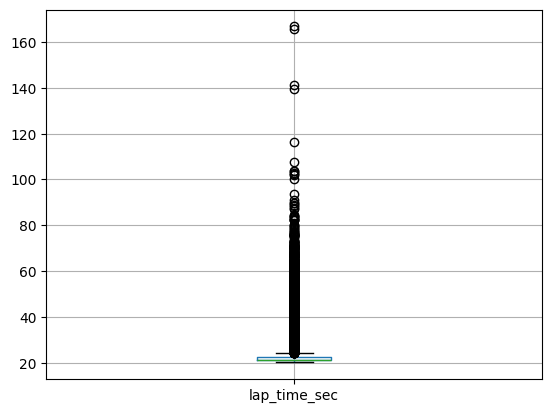

In [26]:

TRACK_LENGTH_MI = 0.526
race.telemetry.lap_times['lap_time_sec'] = (TRACK_LENGTH_MI * 3600) / race.telemetry.lap_times['lap_speed']
race.telemetry.lap_times[race.telemetry.lap_times['lap_time_sec']>0].boxplot(column='lap_time_sec')
plt.show()


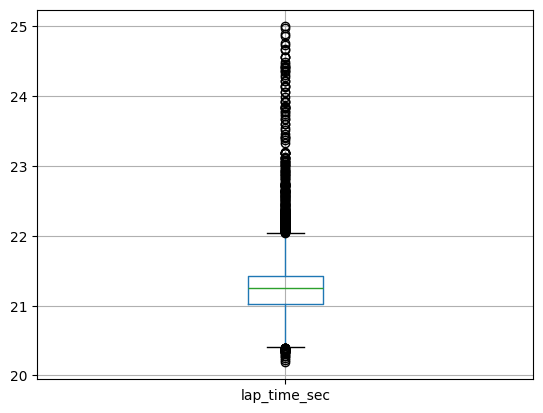

In [27]:
race.telemetry.lap_times[race.telemetry.lap_times['lap_time_sec']<25].boxplot(column='lap_time_sec')
plt.show()

Green-flag lap times at Martinsville (Cook Out 400, 2025): median 21.25s, IQR 21.0–21.5s. Fresh-tire laps drop as low as 20.4s; worn-tire laps drift up to 22s. Approximate degradation: ~1 second per ~80-lap run.